In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , RobustScaler
from sklearn.cluster import KMeans , AgglomerativeClustering , DBSCAN
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA , LatentDirichletAllocation ,KernelPCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv('/Customer_Data.csv',index_col = 'CUST_ID')
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8950 entries, C10001 to C19190
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CRED

# EDA & Visualization

In [5]:
df.isna().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [6]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

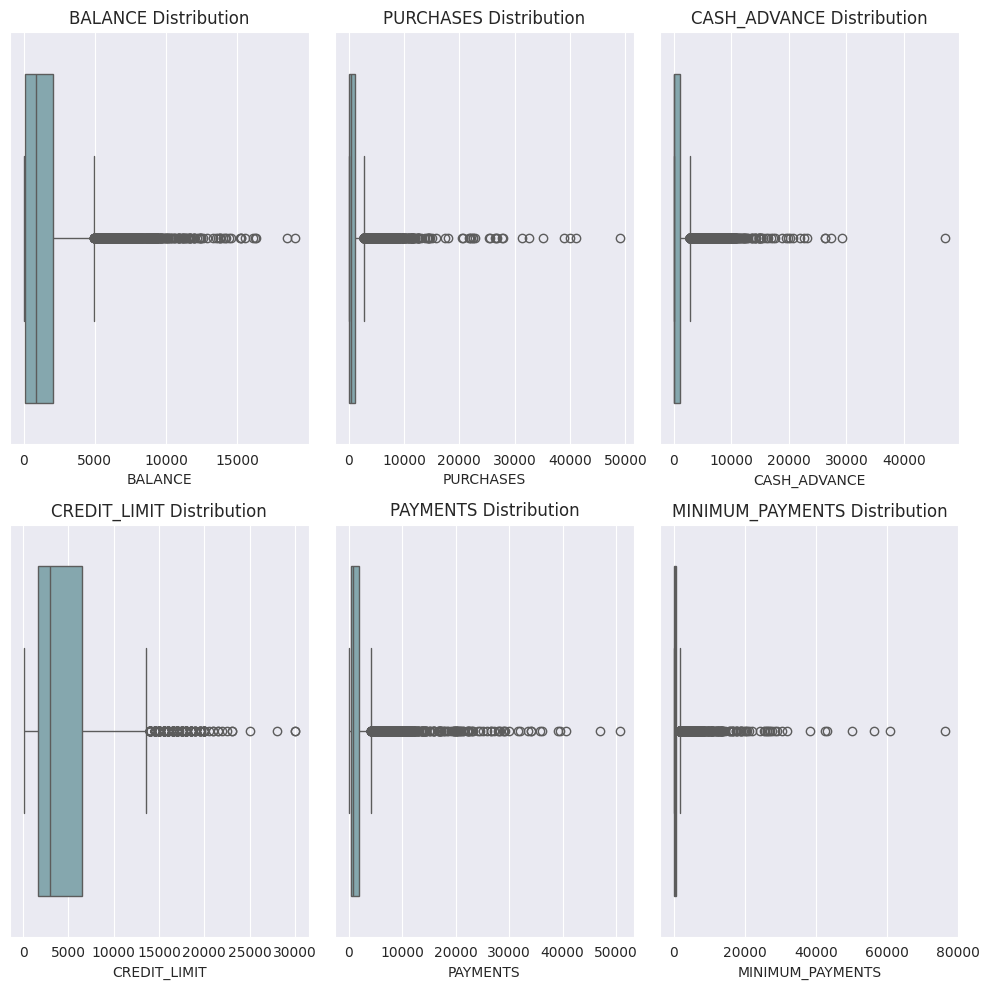

In [7]:
fig  , ax  = plt.subplots(2,3,figsize = (10,10))

sns.boxplot(data = df , x = 'BALANCE',color='#7EACB5',ax = ax[0,0])
ax[0,0].set_title('BALANCE Distribution')

sns.boxplot(data = df , x = 'PURCHASES',color='#7EACB5',ax = ax[0,1])
ax[0,1].set_title('PURCHASES Distribution')

sns.boxplot(data = df , x = 'CASH_ADVANCE',color='#7EACB5',ax = ax[0,2])
ax[0,2].set_title('CASH_ADVANCE Distribution')

sns.boxplot(data = df , x = 'CREDIT_LIMIT',color='#7EACB5',ax = ax[1,0])
ax[1,0].set_title('CREDIT_LIMIT Distribution')

sns.boxplot(data = df , x = 'PAYMENTS',color='#7EACB5',ax = ax[1,1])
ax[1,1].set_title('PAYMENTS Distribution')

sns.boxplot(data = df , x = 'MINIMUM_PAYMENTS',color='#7EACB5',ax = ax[1,2])
ax[1,2].set_title('MINIMUM_PAYMENTS Distribution')

plt.tight_layout()
plt.show()

In [8]:
purchases_zero = df[df['PURCHASES'] == 0]
ratio = (len(purchases_zero)/len(df))*100
print("ratio of people that purchased = 0 : ", np.round(ratio),'%')

ratio of people that purchased = 0 :  23.0 %


In [9]:
cash_zero = df[df['CASH_ADVANCE'] == 0]
ratio = (len(cash_zero)/len(df))*100
print("ratio of people that cash_advance = 0 : ", np.round(ratio),'%')

ratio of people that cash_advance = 0 :  52.0 %


correlation =  0.3569769240769148


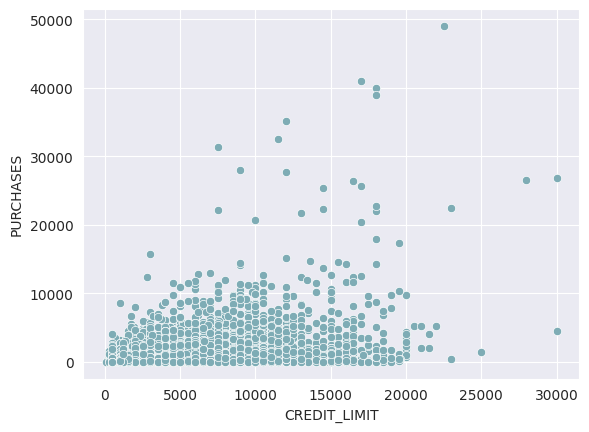

In [10]:
print('correlation = ',np.corrcoef(df['CREDIT_LIMIT'],df['PURCHASES'])[0,1])
sns.scatterplot(data = df , x = 'CREDIT_LIMIT',y = 'PURCHASES',color = '#7EACB5')
plt.xlabel('CREDIT_LIMIT')
plt.ylabel('PURCHASES')
plt.show()

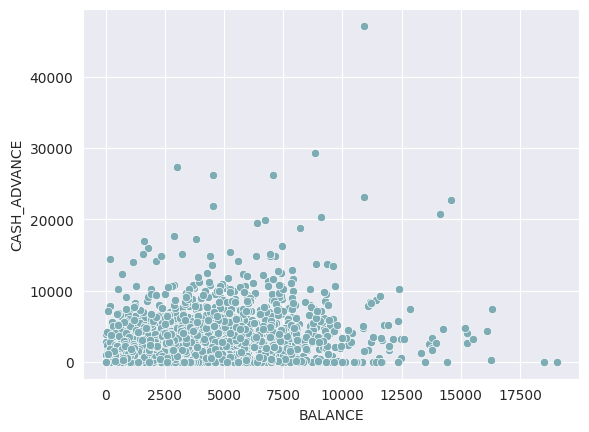

In [11]:
sns.scatterplot(data = df , x = 'BALANCE',y = 'CASH_ADVANCE',color = '#7EACB5')
plt.xlabel('BALANCE')
plt.ylabel('CASH_ADVANCE')
plt.show()

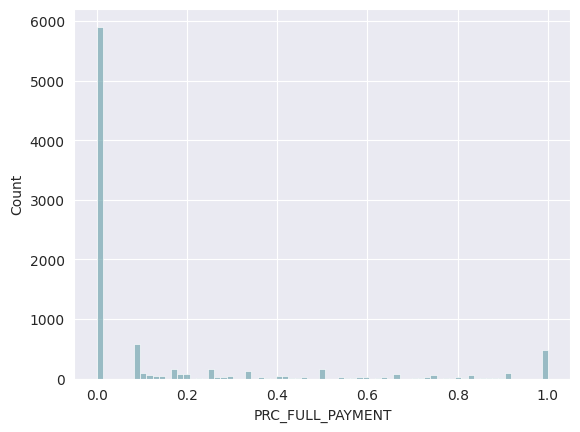

In [12]:
sns.histplot(data = df , x = 'PRC_FULL_PAYMENT',color = '#7EACB5')
plt.xlabel('PRC_FULL_PAYMENT')
plt.show()

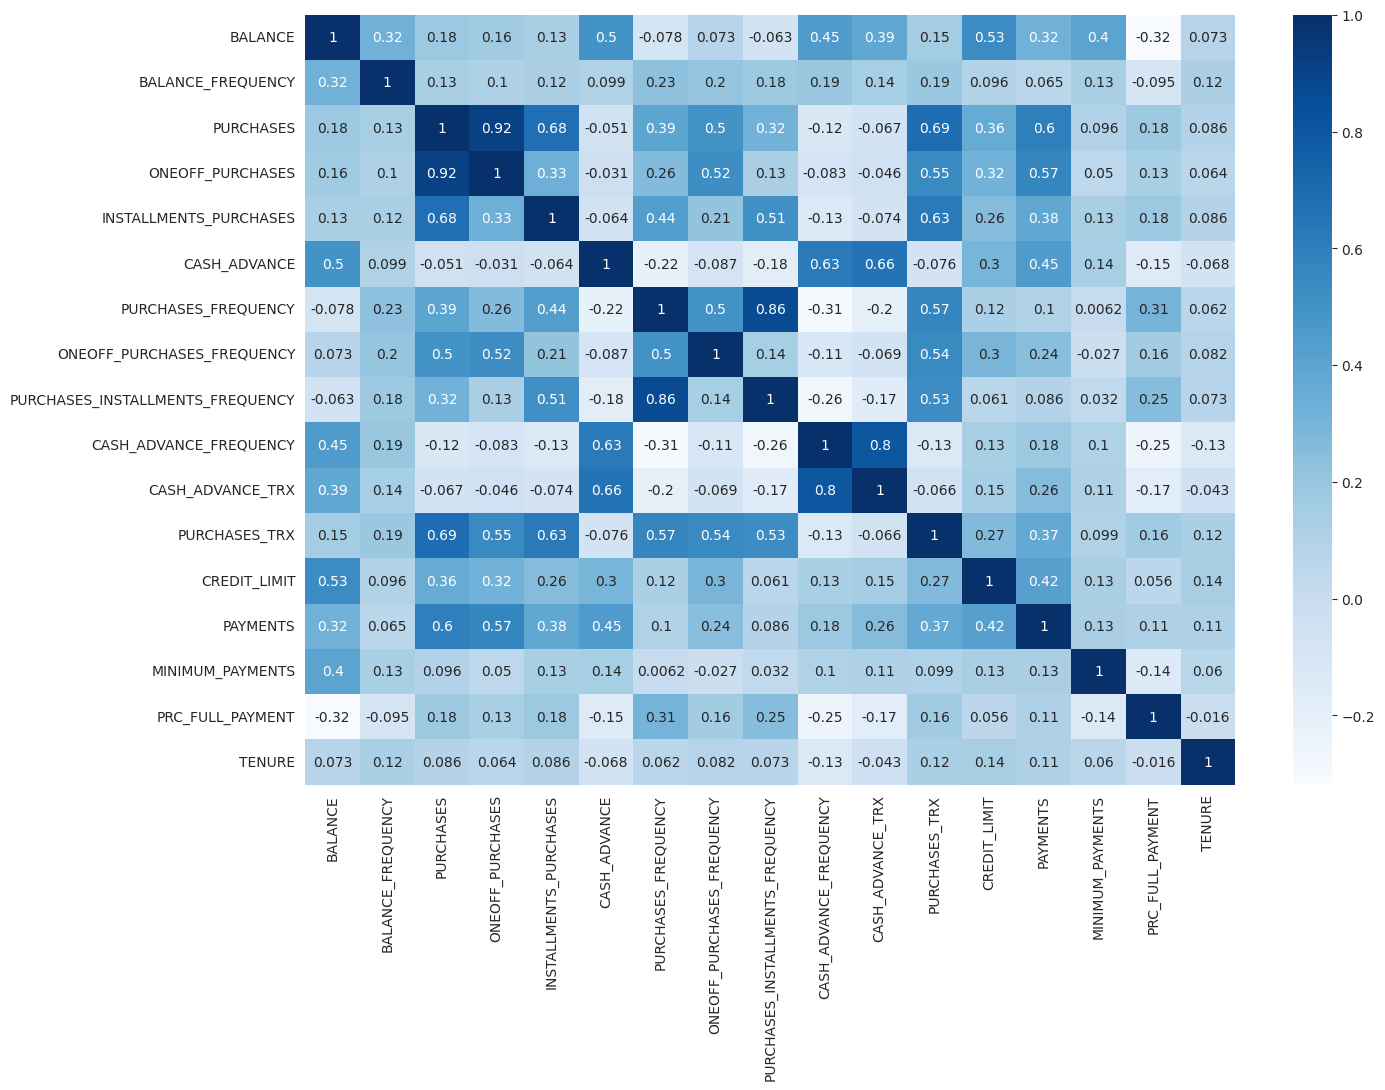

In [13]:
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(),annot = True,cmap = 'Blues')
plt.show()

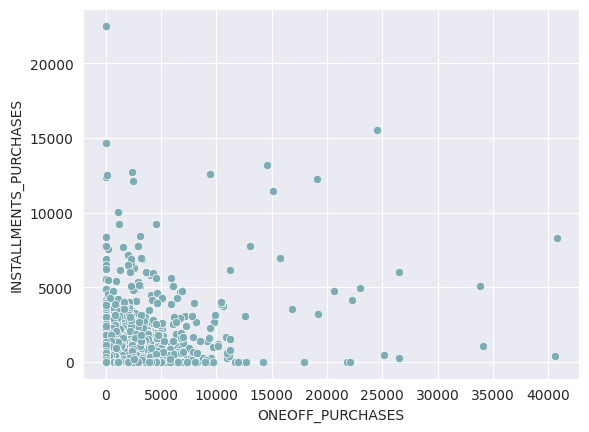

In [14]:
sns.scatterplot(data = df , x = 'ONEOFF_PURCHASES',y = 'INSTALLMENTS_PURCHASES',color = '#7EACB5')
plt.xlabel('ONEOFF_PURCHASES')
plt.ylabel('INSTALLMENTS_PURCHASES')
plt.show()

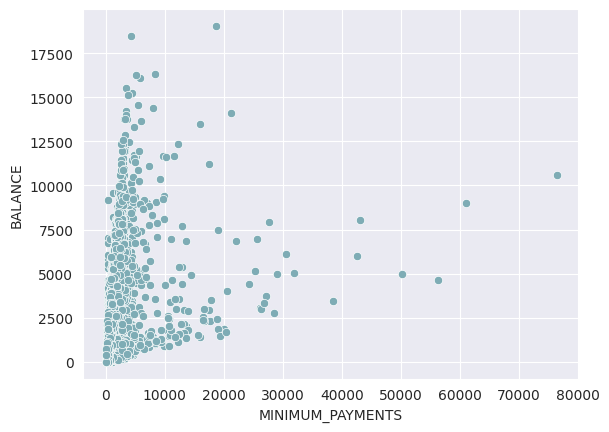

In [15]:
sns.scatterplot(data = df , x = 'MINIMUM_PAYMENTS',y = 'BALANCE', color = '#7EACB5')
plt.xlabel('MINIMUM_PAYMENTS')
plt.ylabel('BALANCE')
plt.show()

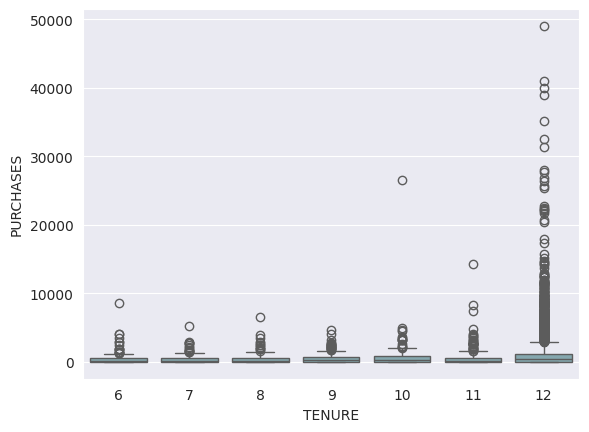

In [16]:
sns.boxplot(data = df , x = 'TENURE',y = 'PURCHASES', color = '#7EACB5')
plt.xlabel('TENURE')
plt.ylabel('PURCHASES')
plt.show()

# Preprocessing Dimentionality Reduction

In [17]:
num_cols = ['BALANCE','PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES','CASH_ADVANCE',
           'CASH_ADVANCE_TRX', 'PURCHASES_TRX','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS','TENURE']

ratio_cols = ['BALANCE_FREQUENCY','PURCHASES_FREQUENCY','ONEOFF_PURCHASES_FREQUENCY','PURCHASES_INSTALLMENTS_FREQUENCY',
             'CASH_ADVANCE_FREQUENCY','PRC_FULL_PAYMENT' ]

In [18]:
X_log = df[num_cols].apply(np.log1p)

In [19]:
scalar = RobustScaler()
scalar.fit(X_log)

X_num = scalar.transform(X_log)
X_num = pd.DataFrame(X_num,columns = num_cols)

In [20]:
scalar = StandardScaler()
scalar.fit(df[ratio_cols])

X_ratio = scalar.transform(df[ratio_cols])
X_ratio = pd.DataFrame(X_ratio,columns = ratio_cols)

In [21]:
X_feaures = pd.concat([X_num,X_ratio],axis = 1)

In [22]:
pca = PCA(n_components = 0.95)
X_features_pca = pca.fit_transform(X_feaures)

In [23]:
pca.explained_variance_ratio_.cumsum()

array([0.34899197, 0.57742065, 0.67681453, 0.76664868, 0.83550048,
       0.89039393, 0.92376476, 0.94620098, 0.96753137])

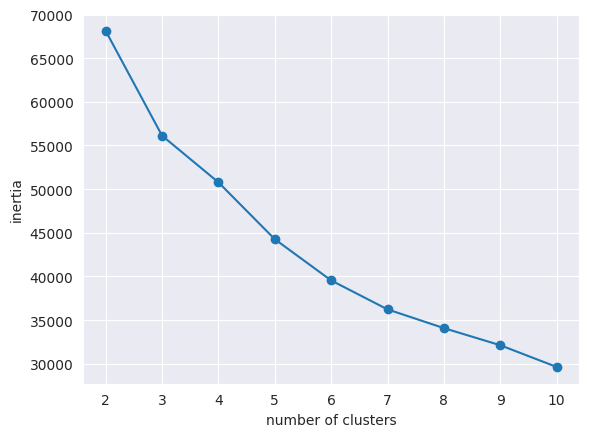

In [24]:
inertia = []

for i in range(2,11):
  kmeans = KMeans(n_clusters = i,random_state = 42)
  kmeans.fit(X_features_pca)
  inertia.append(kmeans.inertia_)


plt.plot(range(2,11),inertia,marker = 'o')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.show()

In [25]:
score = []
for i in range(2,11):
  kmeans = KMeans(n_clusters = i,random_state = 42)
  kmeans.fit(X_features_pca)
  inertia.append(kmeans.inertia_)
  labels  = kmeans.labels_
  score = silhouette_score(X_features_pca,labels)
  print(f"number of clusters = {i} , score = {score}")

number of clusters = 2 , score = 0.2614732428119851
number of clusters = 3 , score = 0.2746169914819109
number of clusters = 4 , score = 0.20898876069781758
number of clusters = 5 , score = 0.22401515017841747
number of clusters = 6 , score = 0.24386260109929025
number of clusters = 7 , score = 0.24261724625754633
number of clusters = 8 , score = 0.24587383503611548
number of clusters = 9 , score = 0.2271234434224999
number of clusters = 10 , score = 0.23640648503335346


In [26]:
k = 3
K_mean = KMeans(n_clusters = k,random_state = 42)
K_mean.fit(X_features_pca)
labels = K_mean.labels_

df['Cluster'] = labels

# Analysis Clusters

In [27]:
df['Cluster'].value_counts()

,count
Cluster,
0,4199
2,3189
1,1562


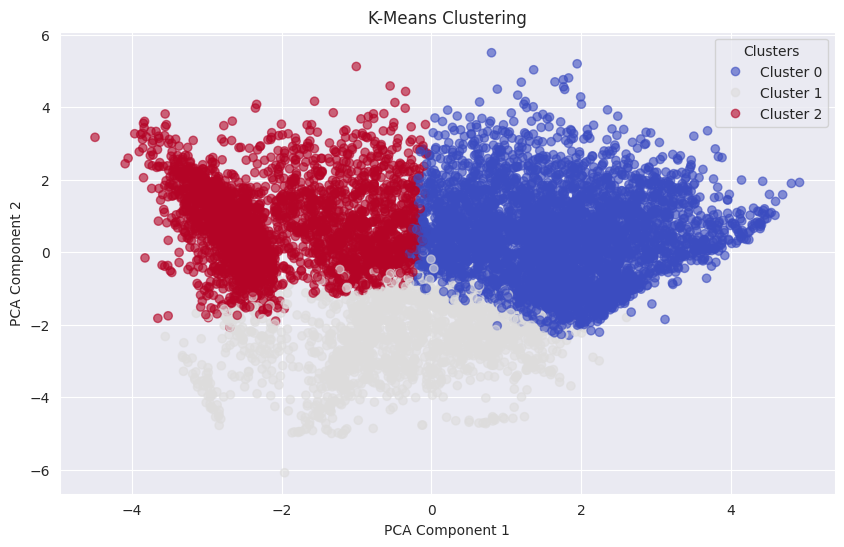

In [28]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_features_pca[:, 0], X_features_pca[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering')
legend_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']
handles, _ = scatter.legend_elements()
plt.legend(handles, legend_labels , title="Clusters")
plt.show()

In [29]:
cluster_summary =df.groupby('Cluster').median()
cluster_summary = cluster_summary[['BALANCE','PURCHASES','CASH_ADVANCE',
                               'CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT']]

cluster_summary

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
Cluster,,,,,,
0,763.327047,1058.580,0.000000,4000.0,1177.010626,0.0
1,25.341136,187.525,0.000000,2700.0,309.080076,0.0
2,1601.692049,0.000,1124.284462,3000.0,816.236790,0.0


In [30]:
df_cluster_one = cluster_summary.iloc[0]
df_cluster_two = cluster_summary.iloc[1]
df_cluster_three = cluster_summary.iloc[2]

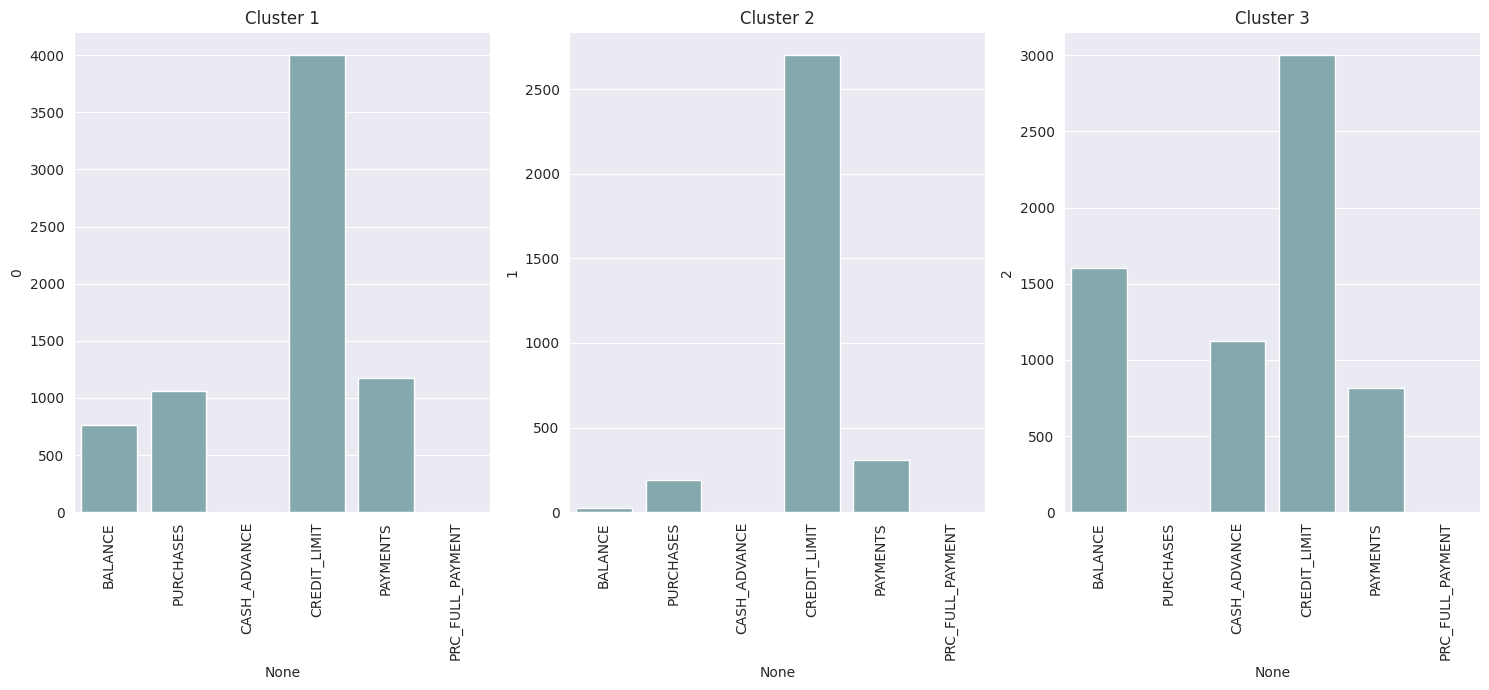

In [31]:
fig , ax = plt.subplots(1,3,figsize = (15,7))

sns.barplot(x = df_cluster_one.index,y = df_cluster_one,ax = ax[0],color='#7EACB5')
ax[0].set_title('Cluster 1')
ax[0].set_xticklabels(df_cluster_one.index,rotation = 90)

sns.barplot(x = df_cluster_two.index,y = df_cluster_two,ax = ax[1],color='#7EACB5')
ax[1].set_title('Cluster 2')
ax[1].set_xticklabels(df_cluster_two.index,rotation = 90)

sns.barplot(x = df_cluster_three.index,y=df_cluster_three,ax = ax[2],color='#7EACB5')
ax[2].set_title('Cluster 3')
ax[2].set_xticklabels(df_cluster_three.index,rotation = 90)

plt.tight_layout()
plt.show()


Cluster 0: Active retail spenders with moderate balance and healthy repayment behavior.

Cluster 1: Low-activity customers with minimal engagement.

Cluster 2: High-risk segment relying heavily on cash advances with elevated balances.

In [32]:
df_cluster_one = df[df['Cluster'] == 0]
df_cluster_two = df[df['Cluster'] == 1]
df_cluster_three = df[df['Cluster']==2]

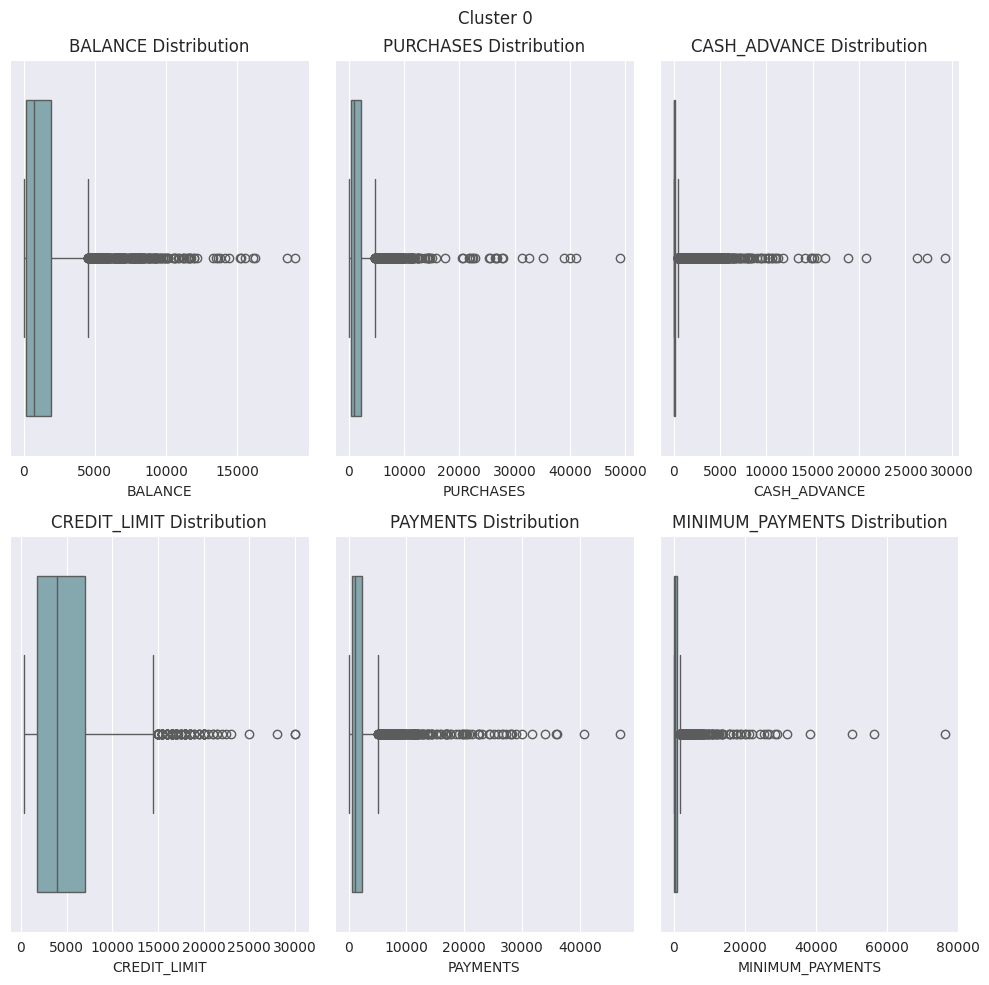

In [33]:
fig  , ax  = plt.subplots(2,3,figsize = (10,10))
fig.suptitle('Cluster 0')
sns.boxplot(data = df_cluster_one , x = 'BALANCE',color='#7EACB5',ax = ax[0,0])
ax[0,0].set_title('BALANCE Distribution')

sns.boxplot(data = df_cluster_one , x = 'PURCHASES',color='#7EACB5',ax = ax[0,1])
ax[0,1].set_title('PURCHASES Distribution')

sns.boxplot(data = df_cluster_one , x = 'CASH_ADVANCE',color='#7EACB5',ax = ax[0,2])
ax[0,2].set_title('CASH_ADVANCE Distribution')

sns.boxplot(data = df_cluster_one , x = 'CREDIT_LIMIT',color='#7EACB5',ax = ax[1,0])
ax[1,0].set_title('CREDIT_LIMIT Distribution')

sns.boxplot(data = df_cluster_one , x = 'PAYMENTS',color='#7EACB5',ax = ax[1,1])
ax[1,1].set_title('PAYMENTS Distribution')

sns.boxplot(data = df_cluster_one , x = 'MINIMUM_PAYMENTS',color='#7EACB5',ax = ax[1,2])
ax[1,2].set_title('MINIMUM_PAYMENTS Distribution')

plt.tight_layout()
plt.show()

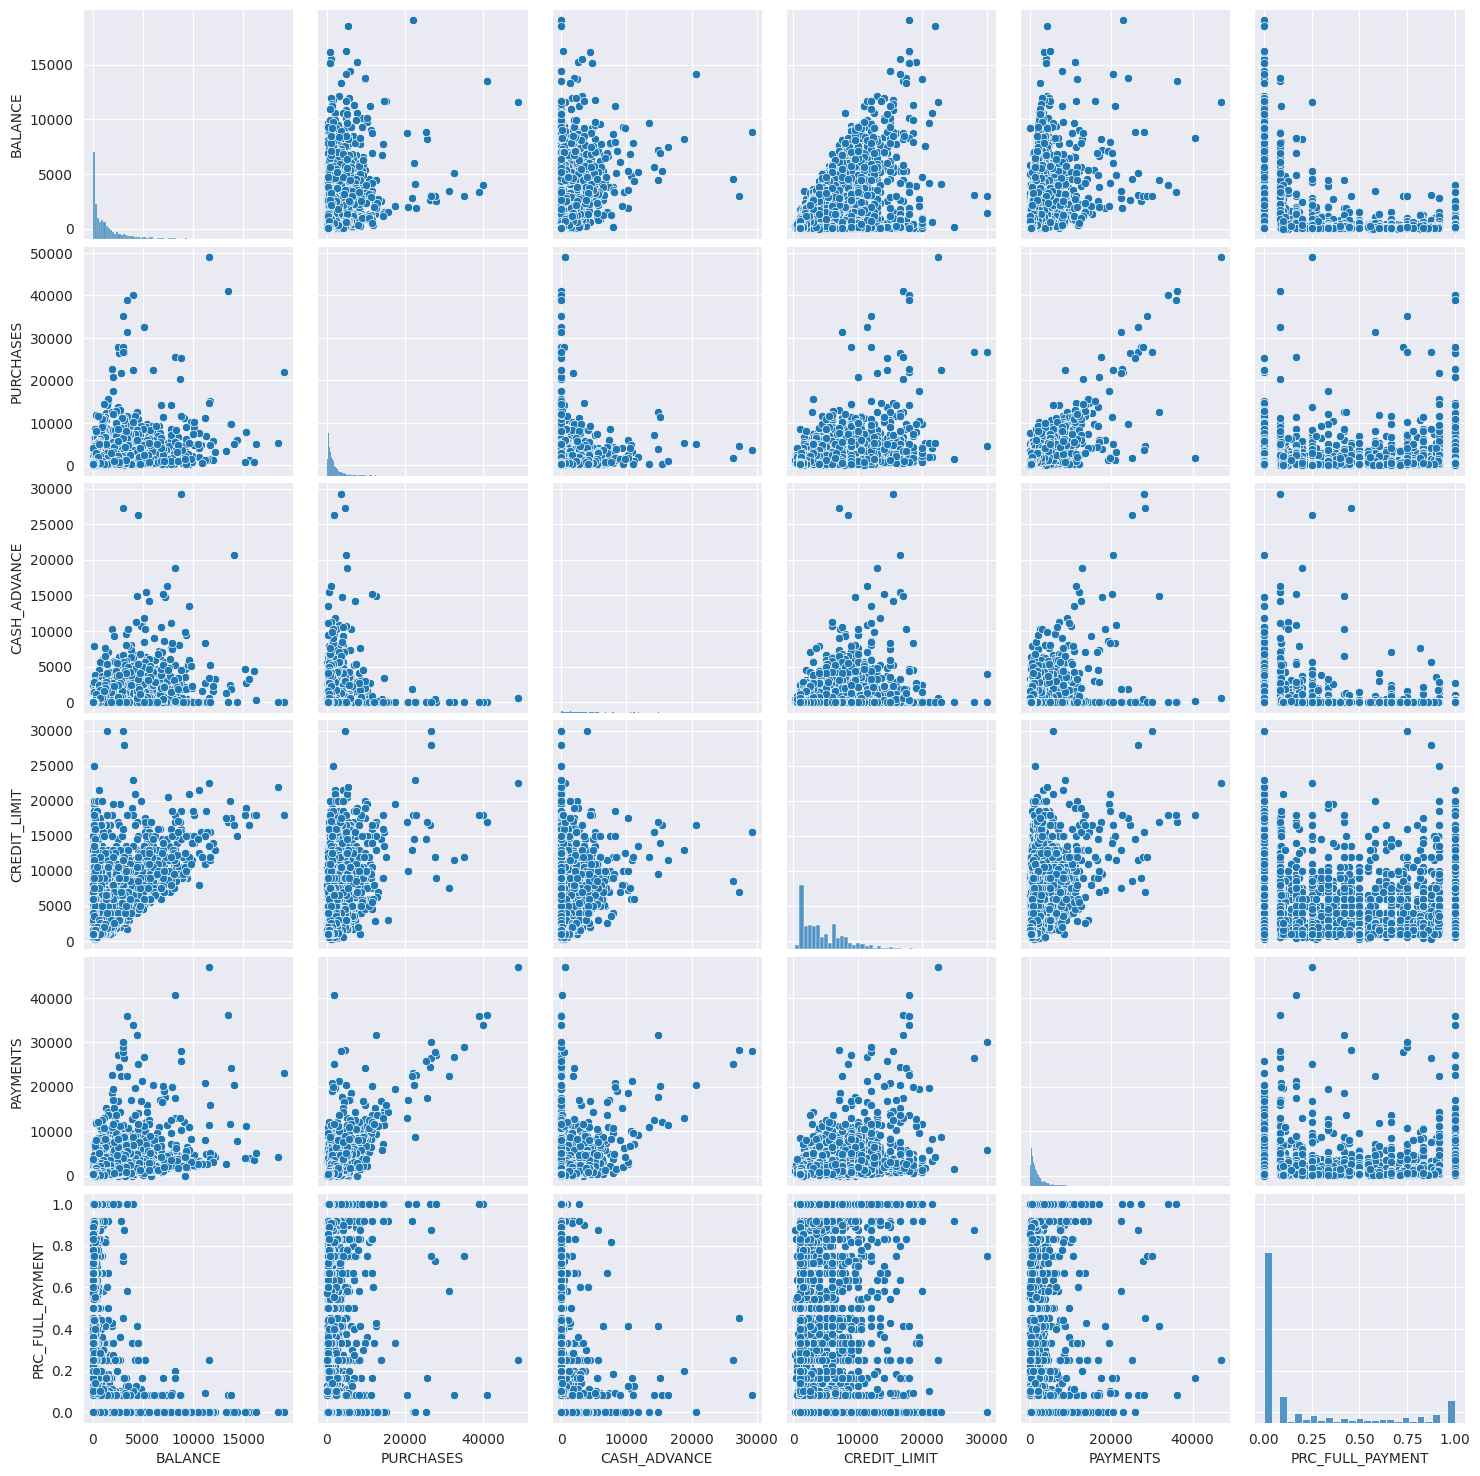

In [34]:
sns.pairplot(df_cluster_one[['BALANCE','PURCHASES','CASH_ADVANCE',
                               'CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT']])
plt.show()

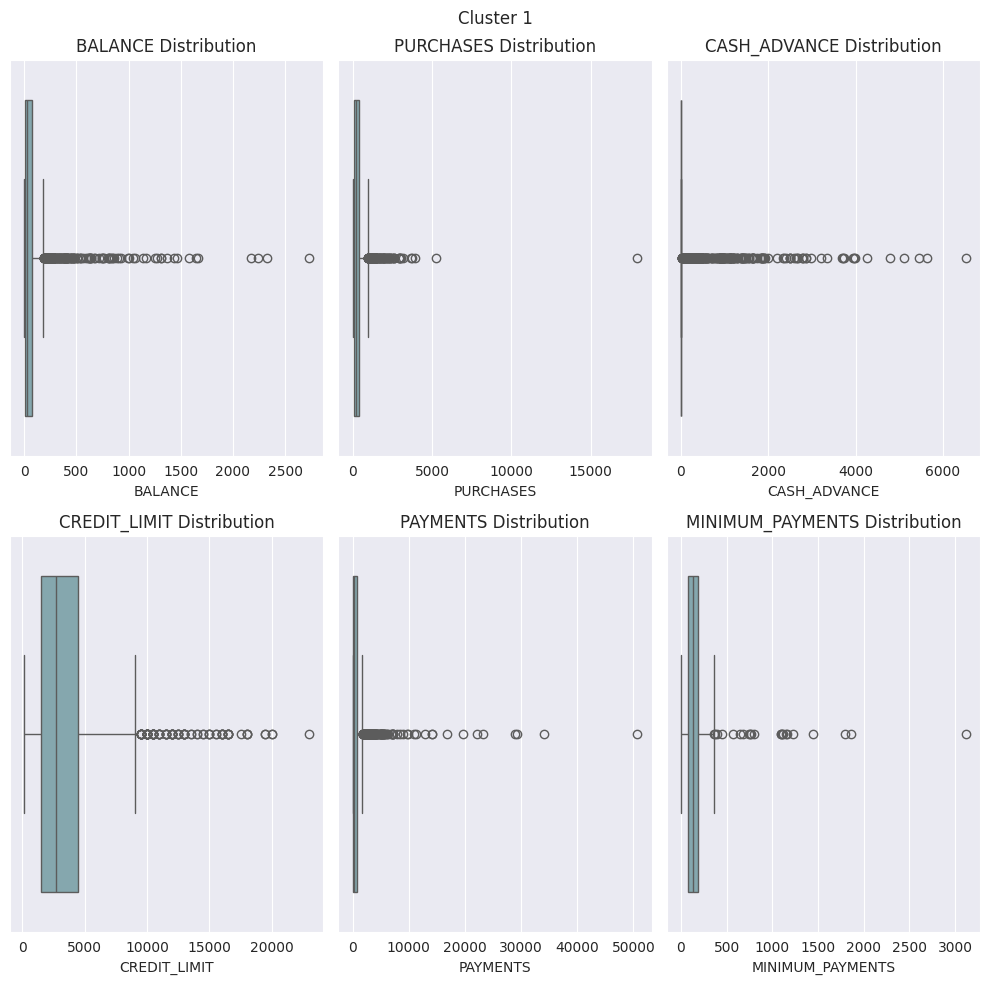

In [35]:
fig  , ax  = plt.subplots(2,3,figsize = (10,10))
fig.suptitle('Cluster 1')
sns.boxplot(data = df_cluster_two , x = 'BALANCE',color='#7EACB5',ax = ax[0,0])
ax[0,0].set_title('BALANCE Distribution')

sns.boxplot(data = df_cluster_two , x = 'PURCHASES',color='#7EACB5',ax = ax[0,1])
ax[0,1].set_title('PURCHASES Distribution')

sns.boxplot(data = df_cluster_two , x = 'CASH_ADVANCE',color='#7EACB5',ax = ax[0,2])
ax[0,2].set_title('CASH_ADVANCE Distribution')

sns.boxplot(data = df_cluster_two , x = 'CREDIT_LIMIT',color='#7EACB5',ax = ax[1,0])
ax[1,0].set_title('CREDIT_LIMIT Distribution')

sns.boxplot(data = df_cluster_two , x = 'PAYMENTS',color='#7EACB5',ax = ax[1,1])
ax[1,1].set_title('PAYMENTS Distribution')

sns.boxplot(data = df_cluster_two , x = 'MINIMUM_PAYMENTS',color='#7EACB5',ax = ax[1,2])
ax[1,2].set_title('MINIMUM_PAYMENTS Distribution')

plt.tight_layout()
plt.show()


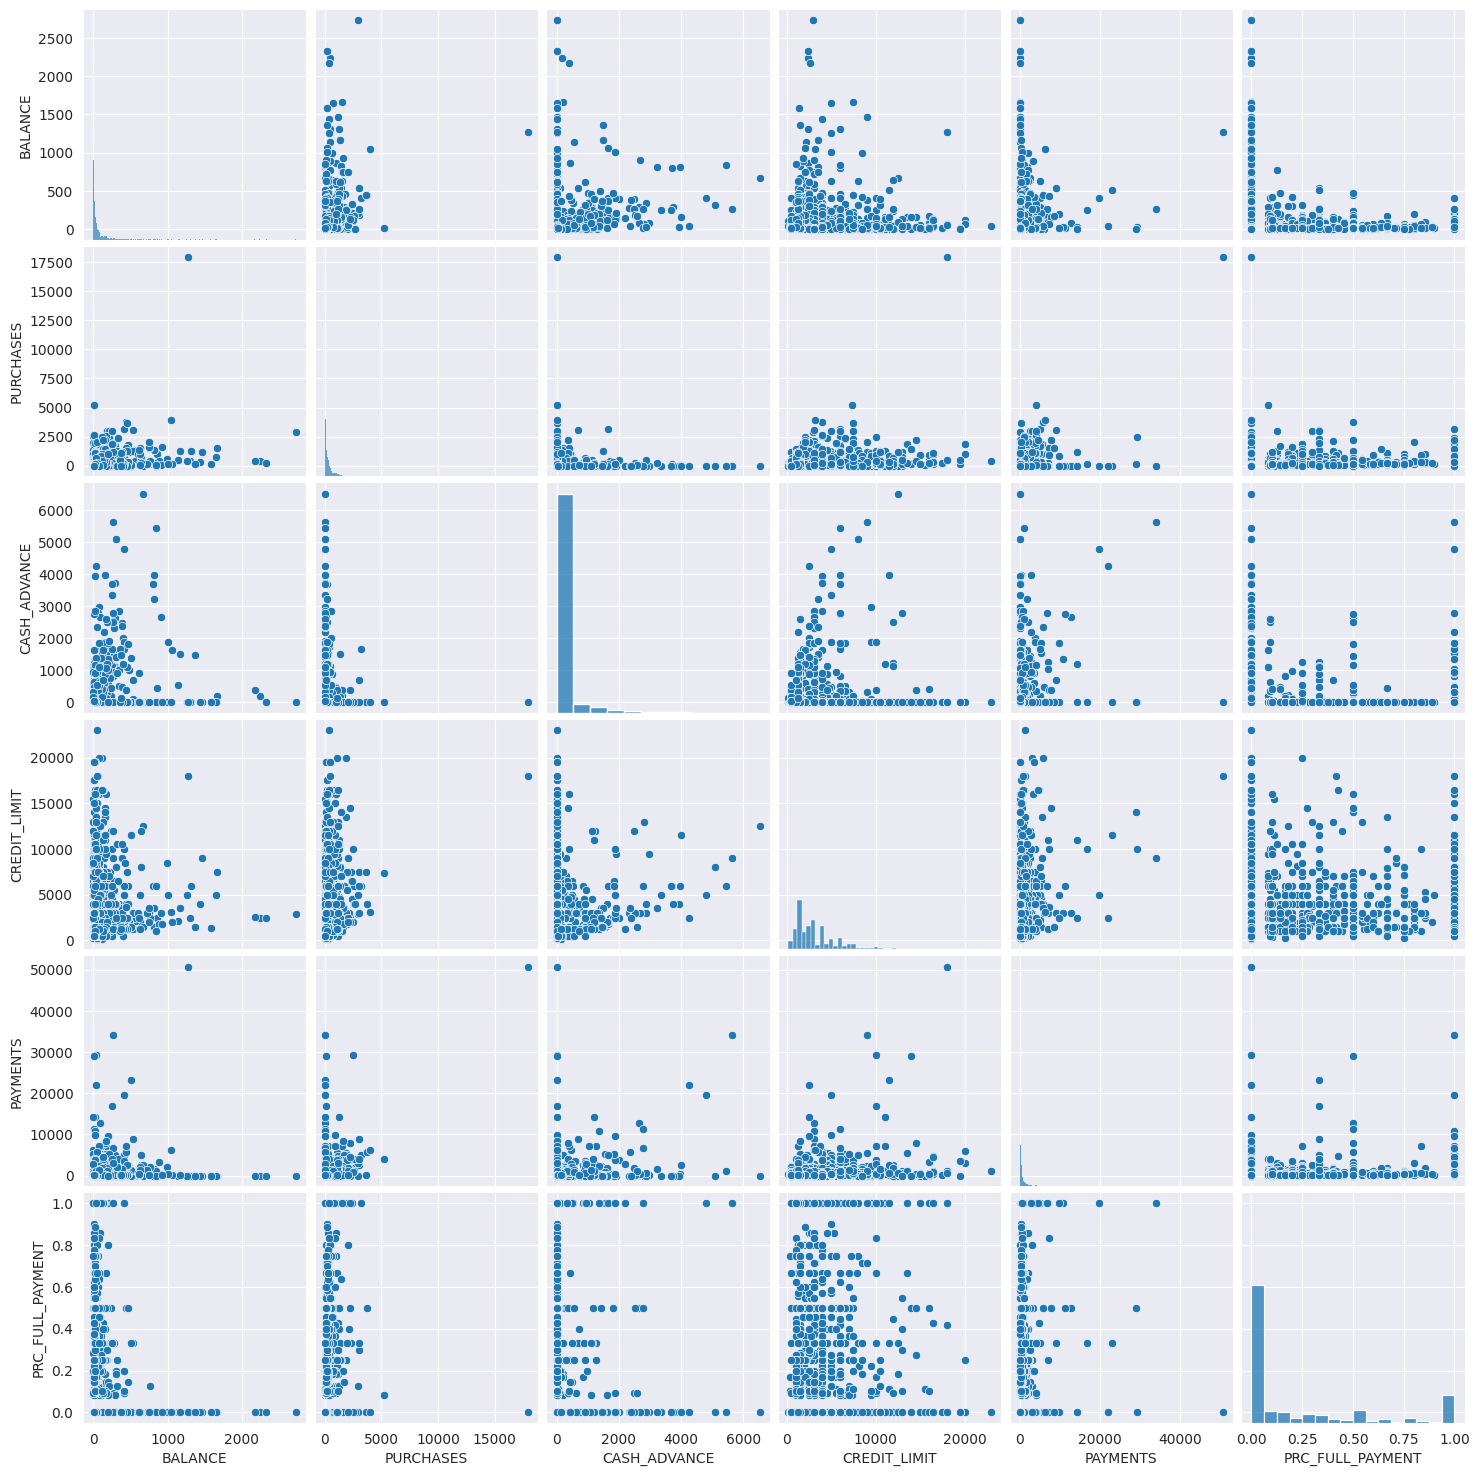

In [36]:
sns.pairplot(df_cluster_two[['BALANCE','PURCHASES','CASH_ADVANCE',
                               'CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT']])
plt.show()

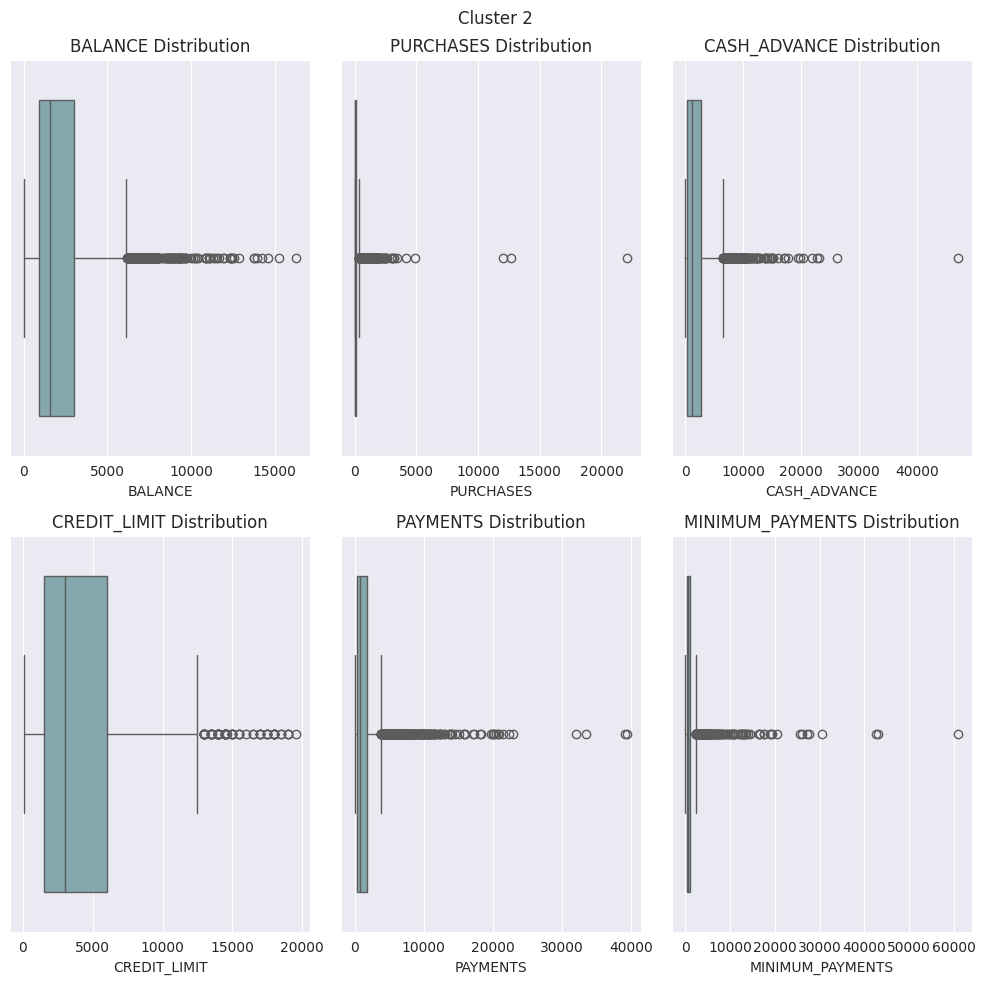

In [37]:
fig  , ax  = plt.subplots(2,3,figsize = (10,10))
fig.suptitle('Cluster 2')
sns.boxplot(data = df_cluster_three , x = 'BALANCE',color='#7EACB5',ax = ax[0,0])
ax[0,0].set_title('BALANCE Distribution')

sns.boxplot(data = df_cluster_three , x = 'PURCHASES',color='#7EACB5',ax = ax[0,1])
ax[0,1].set_title('PURCHASES Distribution')

sns.boxplot(data = df_cluster_three , x = 'CASH_ADVANCE',color='#7EACB5',ax = ax[0,2])
ax[0,2].set_title('CASH_ADVANCE Distribution')

sns.boxplot(data = df_cluster_three , x = 'CREDIT_LIMIT',color='#7EACB5',ax = ax[1,0])
ax[1,0].set_title('CREDIT_LIMIT Distribution')

sns.boxplot(data = df_cluster_three , x = 'PAYMENTS',color='#7EACB5',ax = ax[1,1])
ax[1,1].set_title('PAYMENTS Distribution')

sns.boxplot(data = df_cluster_three , x = 'MINIMUM_PAYMENTS',color='#7EACB5',ax = ax[1,2])
ax[1,2].set_title('MINIMUM_PAYMENTS Distribution')

plt.tight_layout()
plt.show()

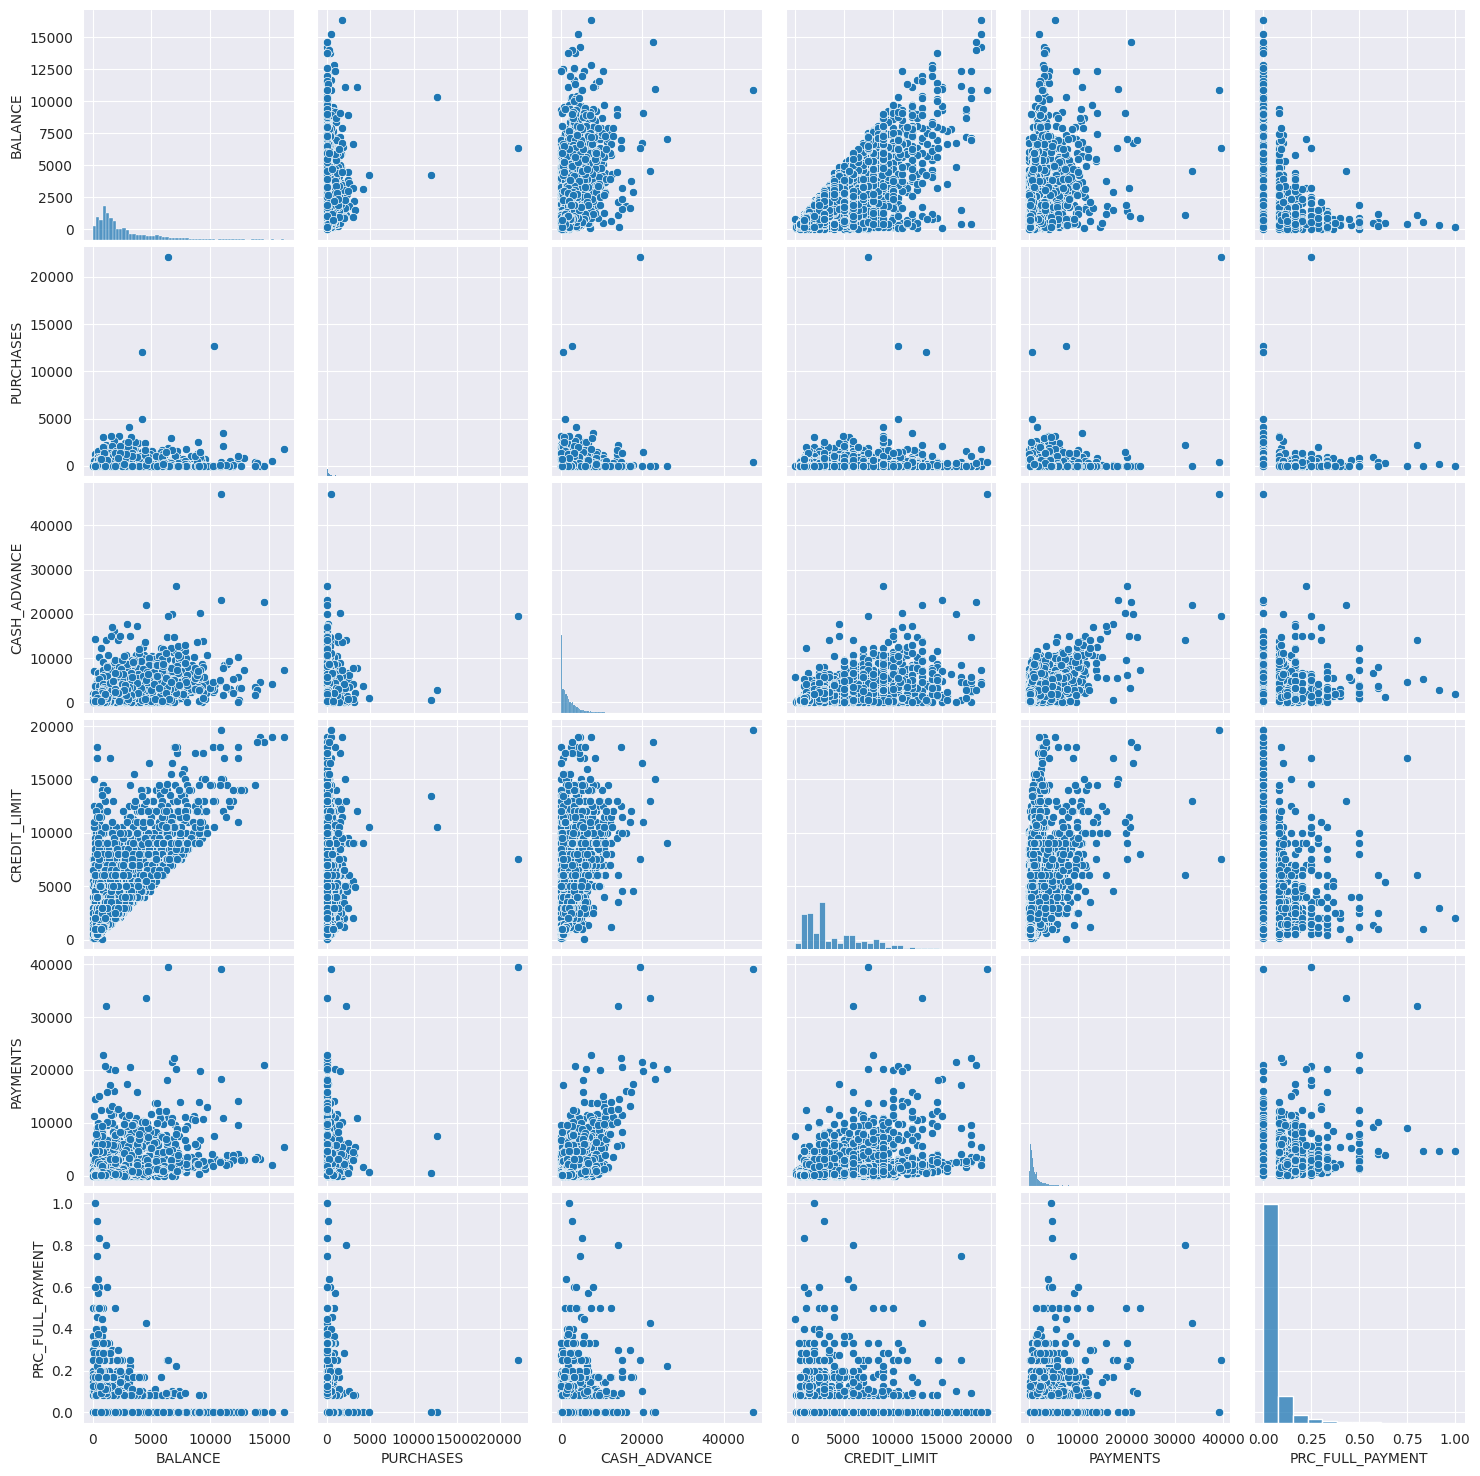

In [43]:
sns.pairplot(df_cluster_three[['BALANCE','PURCHASES','CASH_ADVANCE',
                               'CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT']] )
plt.show()

# Hierarchical Clustering

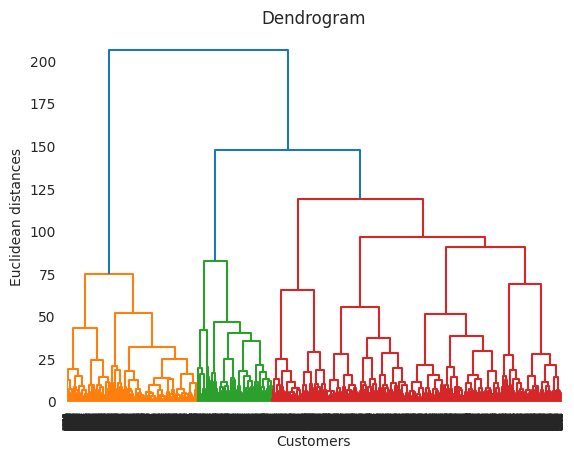

In [51]:
dendrogram = sch.dendrogram(sch.linkage(X_features_pca,method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [52]:
df.drop(columns=['Cluster'],axis =1)
hc = AgglomerativeClustering(n_clusters = 3 ,linkage = 'ward')
hc.fit_predict(X_features_pca)
labels = hc.labels_

df['Cluster'] = labels

In [53]:
score = silhouette_score(X_features_pca,labels)
print('silhouette_score : ',score)

silhouette_score :  0.23902375877043097


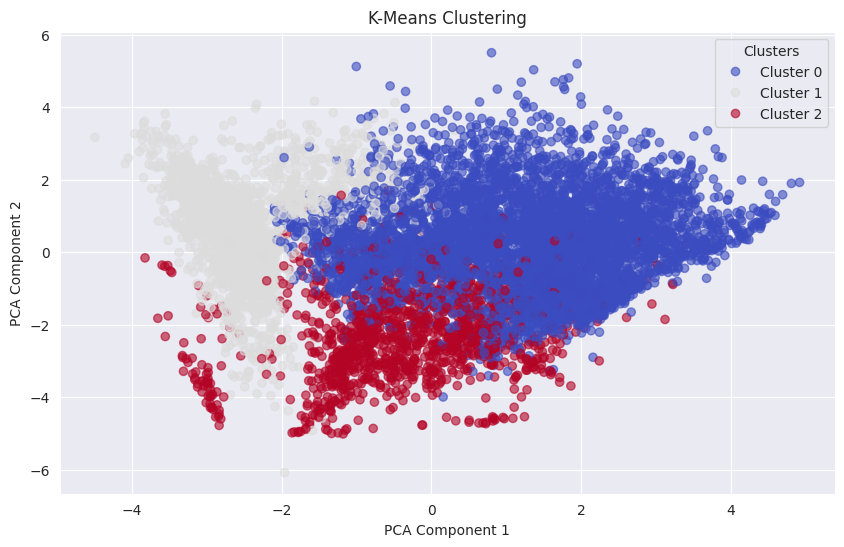

In [54]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_features_pca[:, 0], X_features_pca[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering')
legend_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']
handles, _ = scatter.legend_elements()
plt.legend(handles, legend_labels , title="Clusters")
plt.show()

In [55]:
df['Cluster'].value_counts()

,count
Cluster,
0,5220
1,2387
2,1343


In [56]:
hc_summary = df.groupby('Cluster').median()[['BALANCE','PURCHASES',
                                'CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS'
                                ]]

hc_summary

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
Cluster,,,,,
0,826.151696,792.04,0.00000,3375.0,969.756759
1,1731.623546,0.00,1433.85482,3000.0,954.718474
2,29.602980,244.20,0.00000,3000.0,347.240071


In [57]:
df_cluster_one = hc_summary.iloc[0]
df_cluster_two = hc_summary.iloc[1]
df_cluster_three = hc_summary.iloc[2]

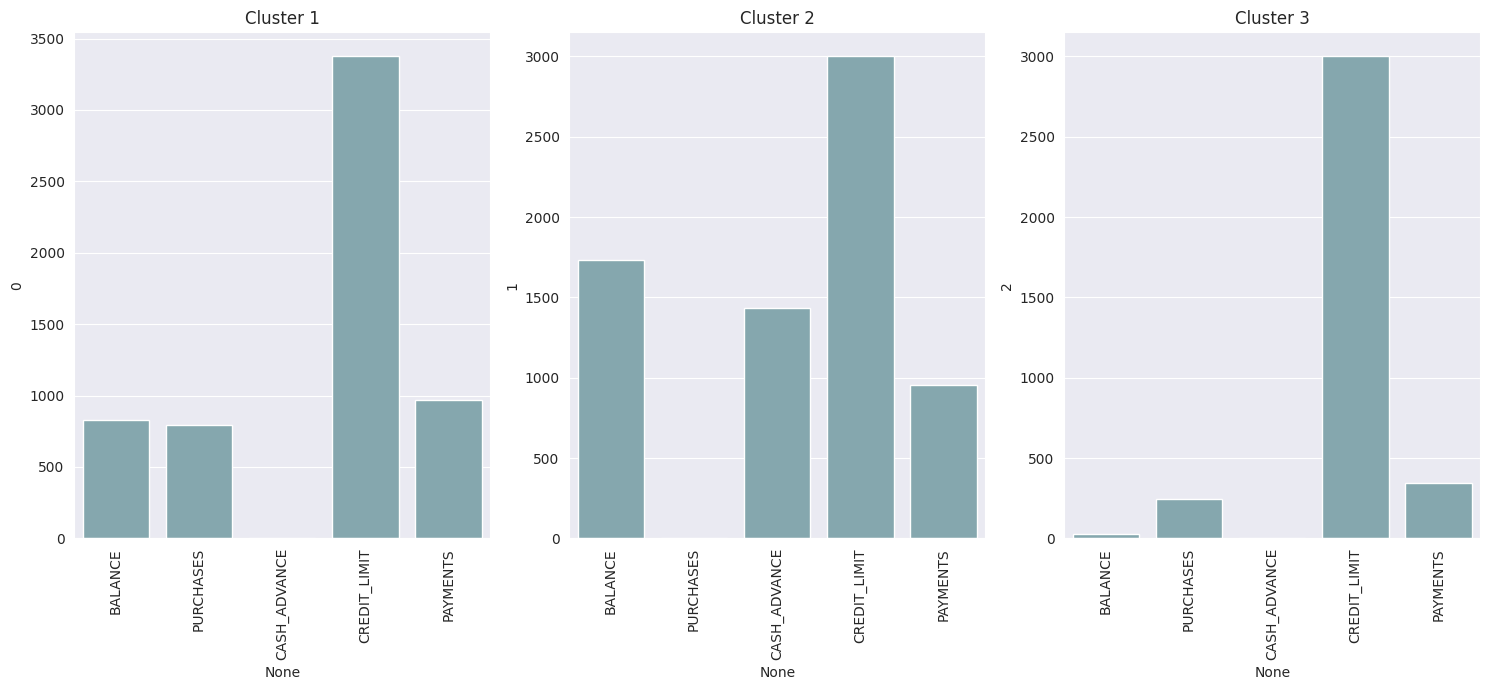

In [58]:
fig , ax = plt.subplots(1,3,figsize = (15,7))

sns.barplot(x = df_cluster_one.index,y = df_cluster_one,ax = ax[0],color='#7EACB5')
ax[0].set_title('Cluster 1')
ax[0].set_xticklabels(df_cluster_one.index,rotation = 90)

sns.barplot(x = df_cluster_two.index,y = df_cluster_two,ax = ax[1],color='#7EACB5')
ax[1].set_title('Cluster 2')
ax[1].set_xticklabels(df_cluster_two.index,rotation = 90)

sns.barplot(x = df_cluster_three.index,y=df_cluster_three,ax = ax[2],color='#7EACB5')
ax[2].set_title('Cluster 3')
ax[2].set_xticklabels(df_cluster_three.index,rotation = 90)

plt.tight_layout()
plt.show()


# DBSCAN

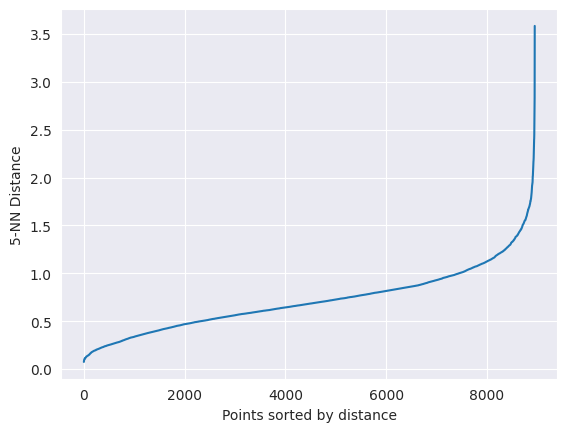

In [44]:
neigboors = NearestNeighbors(n_neighbors = 5)
neigboors_fit= neigboors.fit(X_features_pca)
distances , indices = neigboors_fit.kneighbors(X_features_pca)
distances = distances[:,4]
distances = np.sort(distances)
plt.plot(distances)
plt.ylabel("5-NN Distance")
plt.xlabel("Points sorted by distance")
plt.show()


In [45]:
dbscan = DBSCAN(eps =1.25,min_samples=5)
dbscan.fit(X_features_pca)
labels = dbscan.labels_

df['Cluster'] = labels

In [46]:
score = silhouette_score(X_features_pca[labels!=-1],labels[labels!=-1])
print('silhouette_score : ',score)

silhouette_score :  0.1420595244579257


In [47]:
g=df['Cluster'].value_counts()
g

,count
Cluster,
0,8430
-1,283
3,92
1,71
2,34
6,20
4,10
5,10


In [48]:
legend_labels = []
for i in g.index:
  r = f"Customer{i}"
  legend_labels.append(r)

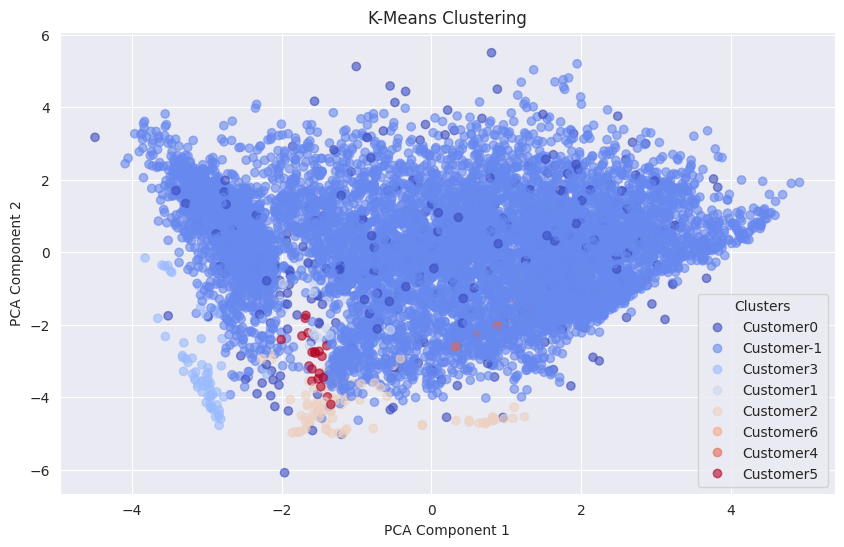

In [49]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_features_pca[:, 0], X_features_pca[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering')
legend_labels = legend_labels
handles, _ = scatter.legend_elements()
plt.legend(handles, legend_labels , title="Clusters")
plt.show()

In [50]:
df.groupby('Cluster').median()[['BALANCE','PURCHASES',
                                'CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS'
                                ]]

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
Cluster,,,,,
-1,358.792227,547.280,551.078807,4500.0,2329.319937
0,928.889779,370.000,0.000000,3000.0,870.767946
1,128.375213,0.000,1156.870667,3000.0,0.000000
2,1196.642103,351.460,0.000000,3050.0,0.000000
3,3.894703,130.150,0.000000,2950.0,0.000000
4,964.227845,1176.725,0.000000,6000.0,0.000000
5,375.362783,732.830,0.000000,2750.0,0.000000
6,14.539343,0.000,430.383122,1200.0,1872.982898
